# 03 · Ensemble Verification — CRPS, Rank Histogram, Spread–Skill

**Runnable companion to [`python-verification-guide.md`](../python-verification-guide.md).**

An ensemble forecast is a probability distribution, so it needs probabilistic
scores. This notebook uses a real 31-member ensemble (GEFS via the Open-Meteo
Ensemble API) for 2-m temperature and verifies it against station observations:

1. **Ensemble plume** vs the observed trajectory.
2. **Rank histogram** — is the ensemble well calibrated (flat) or
   under-/over-dispersed (U-/dome-shaped)?
3. **CRPS** and the CRPS skill score vs a climatological reference.
4. **Spread–skill** — does a larger spread really signal a larger error?

**Station:** Jakarta `WIII`, 4–6 Jun 2026.

> Live data with committed cached fallback; see [`../../NOTEBOOKS.md`](../../NOTEBOOKS.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import properscoring as ps

from meteo_examples import dataio, verif

STATION = "WIII"
LAT, LON = -6.13, 106.65
START, END = "2026-06-04", "2026-06-06"
plt.rcParams["figure.dpi"] = 110

## 1 · Load the ensemble and observations, then align them

In [2]:
ens_long = dataio.open_meteo_ensemble(LAT, LON, START, END, variable="temperature_2m")
# pivot to a (time x member) matrix and keep only fully-populated times
ens_wide = ens_long.pivot_table(index="time", columns="member", values="value").dropna()

obs = dataio.iem_asos(STATION, START, END)
o = obs.dropna(subset=["tmpc"]).copy()
o["valid"] = o["valid"].dt.floor("h")
o = o.groupby("valid", as_index=False)["tmpc"].first().set_index("valid")["tmpc"]

common = ens_wide.index.intersection(o.index)
ens = ens_wide.loc[common].values          # (n_times, n_members)
obs_v = o.loc[common].values               # (n_times,)
print(f"verification times: {len(common)}   |   members: {ens.shape[1]}")

verification times: 48   |   members: 31


## 2 · Ensemble plume vs observations

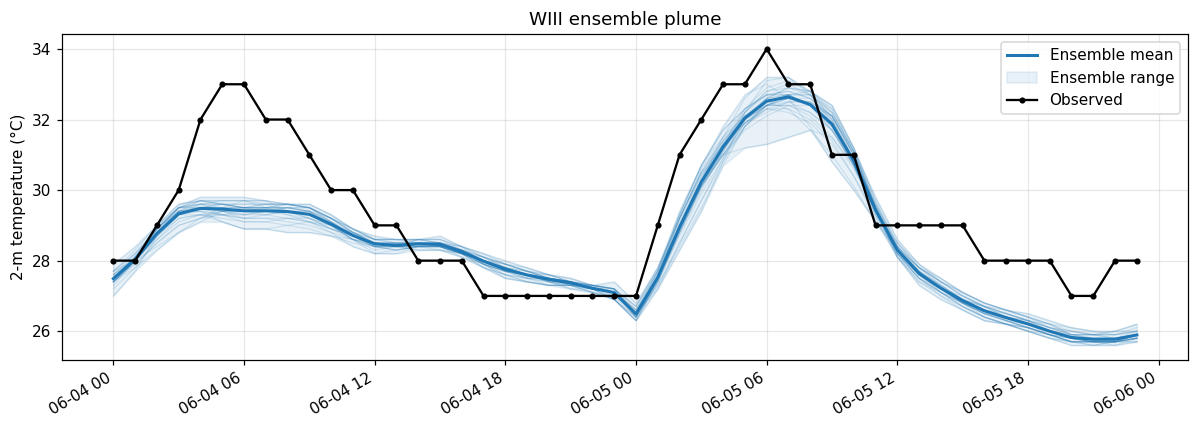

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(common, ens, color="C0", alpha=0.15, lw=0.8)
ax.plot(common, ens.mean(axis=1), color="C0", lw=2, label="Ensemble mean")
ax.fill_between(common, ens.min(axis=1), ens.max(axis=1), color="C0", alpha=0.1,
                label="Ensemble range")
ax.plot(common, obs_v, "k.-", ms=6, label="Observed")
ax.set(ylabel="2-m temperature (°C)", title=f"{STATION} ensemble plume")
ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout()

## 3 · Rank histogram

For each time we rank the observation among the sorted ensemble members. If the
ensemble is reliable, the observation is equally likely to fall in any rank bin,
so the histogram is **flat**. A **U-shape** means the ensemble is
under-dispersive (truth often falls outside it); a **dome** means it is
over-dispersive.

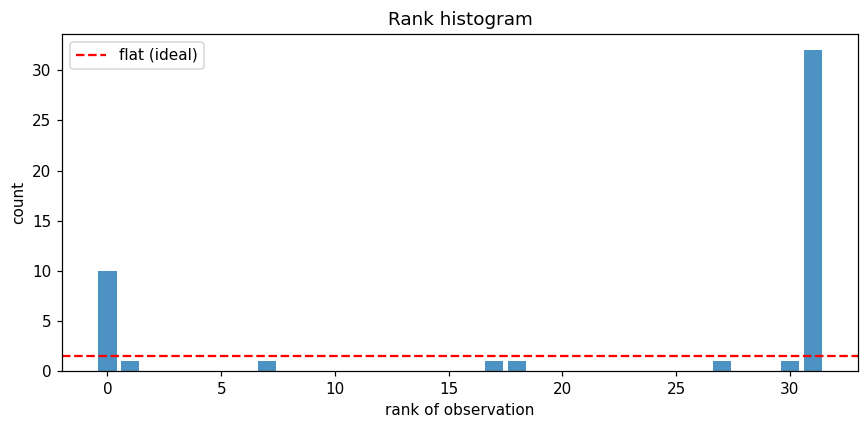

In [4]:
ranks = verif.rank_histogram(ens, obs_v)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(ranks)), ranks, alpha=0.8)
ax.axhline(len(obs_v) / len(ranks), color="r", ls="--", label="flat (ideal)")
ax.set(xlabel="rank of observation", ylabel="count",
       title="Rank histogram"); ax.legend(); plt.tight_layout()

## 4 · CRPS and CRPS skill score

CRPS generalises the absolute error to probabilistic forecasts (lower is
better, same units as the variable). The skill score compares the ensemble's
CRPS to a climatological Gaussian reference built from the observations.

In [5]:
mean_crps, crps_t = verif.crps_ensemble(obs_v, ens)
crps_climo = np.mean(ps.crps_gaussian(obs_v, mu=obs_v.mean(), sig=obs_v.std()))
crpss = 1 - mean_crps / crps_climo
print(f"Ensemble CRPS         : {mean_crps:.3f} °C")
print(f"Climatology CRPS (ref): {crps_climo:.3f} °C")
print(f"CRPS skill score      : {crpss:+.3f}   (1 = perfect, 0 = no better than climatology)")

Ensemble CRPS         : 1.121 °C
Climatology CRPS (ref): 1.235 °C
CRPS skill score      : +0.092   (1 = perfect, 0 = no better than climatology)


## 5 · Spread–skill relationship

A reliable ensemble has spread that *matches* the error of its mean: on average,
ensemble standard deviation ≈ RMSE of the ensemble mean. We also bin times by
spread and check that higher-spread times really do have higher error.

mean ensemble spread (std) : 0.172 °C
RMSE of ensemble mean      : 1.490 °C
spread / RMSE ratio        : 0.12  (≈1 is well-calibrated)


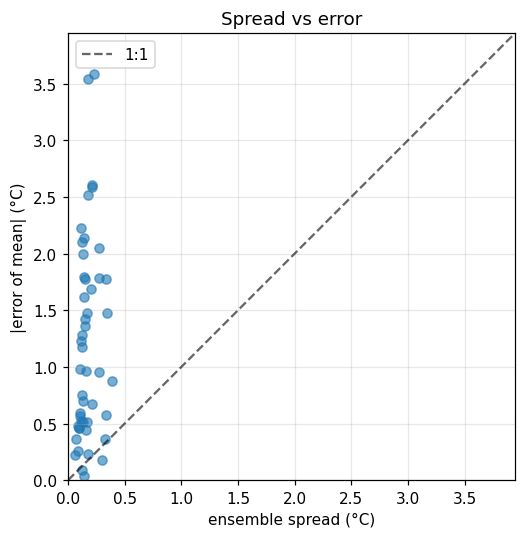

In [6]:
mean_spread, rmse = verif.spread_skill(ens, obs_v)
print(f"mean ensemble spread (std) : {mean_spread:.3f} °C")
print(f"RMSE of ensemble mean      : {rmse:.3f} °C")
print(f"spread / RMSE ratio        : {mean_spread / rmse:.2f}  (≈1 is well-calibrated)")

spread_t = ens.std(axis=1, ddof=1)
err_t = np.abs(ens.mean(axis=1) - obs_v)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(spread_t, err_t, alpha=0.6)
lim = [0, max(spread_t.max(), err_t.max()) * 1.1]
ax.plot(lim, lim, "k--", alpha=0.6, label="1:1")
ax.set(xlabel="ensemble spread (°C)", ylabel="|error of mean| (°C)",
       xlim=lim, ylim=lim, title="Spread vs error"); ax.legend()
ax.set_aspect("equal"); ax.grid(alpha=0.3); plt.tight_layout()

---
### Notes & next steps
- This is a short (~2-day) window, so the histogram is noisy — calibration
  assessment needs many cases. Extend `START`/`END` (and the cache) for a
  smoother picture.
- For event probabilities (e.g. P(rain > 10 mm)) add the Brier score and a
  reliability diagram (`verif.brier_skill_score`, `verif.reliability_data`).
- See the guide's *Ensemble Verification* section for PIT histograms and the
  manual CRPS formulation.